##Basic Imports

In [130]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [70]:
jigsaw = pd.read_csv('https://raw.githubusercontent.com/DavidMembreno/youtube-comment-moderation/main/data/raw/jigsaw/train.csv')
spam = pd.read_csv('https://raw.githubusercontent.com/DavidMembreno/youtube-comment-moderation/main/data/raw/spam/Youtube-Spam-Dataset.csv')
toxic = pd.read_csv('https://raw.githubusercontent.com/DavidMembreno/youtube-comment-moderation/main/data/raw/toxicity/youtoxic_english_1000.csv')

In [71]:
jigsaw.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [72]:
spam.head()

,COMMENT_ID,AUTHOR,DATE,CONTENT,VIDEO_NAME,CLASS
0,LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU,Julius NM,2013-11-07T06:20:48,"Huh, anyway check out this you[tube] channel: ...",PSY - GANGNAM STYLE(?????) M/V,1
1,LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A,adam riyati,2013-11-07T12:37:15,Hey guys check out my new channel and our firs...,PSY - GANGNAM STYLE(?????) M/V,1
2,LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8,Evgeny Murashkin,2013-11-08T17:34:21,just for test I have to say murdev.com,PSY - GANGNAM STYLE(?????) M/V,1
3,z13jhp0bxqncu512g22wvzkasxmvvzjaz04,ElNino Melendez,2013-11-09T08:28:43,me shaking my sexy ass on my channel enjoy ^_^ ﻿,PSY - GANGNAM STYLE(?????) M/V,1
4,z13fwbwp1oujthgqj04chlngpvzmtt3r3dw,GsMega,2013-11-10T16:05:38,watch?v=vtaRGgvGtWQ Check this out .﻿,PSY - GANGNAM STYLE(?????) M/V,1


In [73]:
toxic.head()

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False


Looking at our three datasets here is what we must do in order:

1. Drop 'ID' related columns, they aren't of use to us (same with date)
2. Drop any duplicates that will mess with our models training
3. Drop nulls/NA/blanks within out data if apprproaite only if they can;t be used, somtimes dropping too many rows is too great a loss we will calcualte this
4. Normalize value data types for numerics, objects and text
5. Bining, eaxch dataset deals with comments differenlty we have to decide how to organize them and classify. For example the 'toxic' dataset has alot of boolean categories taht could penteailly be fit into  the jigsaw categories
6. Laslty viusalize correlations, note relationships and export CSV

## Data Cleaning and Processing

In [74]:
df1 = jigsaw
df2 = spam
df3 = toxic

In [75]:
df1 = df1.drop(['id'], axis = 1)
df2 = df2.drop(['COMMENT_ID','AUTHOR','DATE','VIDEO_NAME'], axis =1) # Author, Date, and Vid name are uneeded
df3 = df3.drop(['CommentId','VideoId'],axis = 1)


In [76]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   comment_text   159571 non-null  object
 1   toxic          159571 non-null  int64 
 2   severe_toxic   159571 non-null  int64 
 3   obscene        159571 non-null  int64 
 4   threat         159571 non-null  int64 
 5   insult         159571 non-null  int64 
 6   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 8.5+ MB


In [77]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1956 entries, 0 to 1955
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   CONTENT  1956 non-null   object
 1   CLASS    1956 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 30.7+ KB


In [78]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Text             1000 non-null   object
 1   IsToxic          1000 non-null   bool  
 2   IsAbusive        1000 non-null   bool  
 3   IsThreat         1000 non-null   bool  
 4   IsProvocative    1000 non-null   bool  
 5   IsObscene        1000 non-null   bool  
 6   IsHatespeech     1000 non-null   bool  
 7   IsRacist         1000 non-null   bool  
 8   IsNationalist    1000 non-null   bool  
 9   IsSexist         1000 non-null   bool  
 10  IsHomophobic     1000 non-null   bool  
 11  IsReligiousHate  1000 non-null   bool  
 12  IsRadicalism     1000 non-null   bool  
dtypes: bool(12), object(1)
memory usage: 19.7+ KB


In [79]:
#duplicate check
print("df1: ")
sum(df1.duplicated())
print("df2: ")
sum(df2.duplicated())
print("df3: ")
sum(df3.duplicated())

df1: 
df2: 
df3: 


2

In [80]:
#negligible amount lets drop em
df3.drop_duplicates(inplace = True)

In [81]:
#NA/Null/Blkank checkl rows
print("df1: ")
print(df1.isna().sum())
print("df2: ")
print(df2.isna().sum())
print("df3: ")
print(df3.isna().sum())

# Check for whitespace only strings
print("df1 whitespace only:")
print((df1.apply(lambda x: x.str.strip() == "" if x.dtype == "object" else False)).sum())

df1: 
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64
df2: 
CONTENT    0
CLASS      0
dtype: int64
df3: 
Text               0
IsToxic            0
IsAbusive          0
IsThreat           0
IsProvocative      0
IsObscene          0
IsHatespeech       0
IsRacist           0
IsNationalist      0
IsSexist           0
IsHomophobic       0
IsReligiousHate    0
IsRadicalism       0
dtype: int64
df1 whitespace only:
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


In [82]:
#alright lets rename column names so theya re easy to use
list(df1)

['comment_text',
 'toxic',
 'severe_toxic',
 'obscene',
 'threat',
 'insult',
 'identity_hate']

In [83]:
list(df2)

['CONTENT', 'CLASS']

In [84]:
list(df3)

['Text',
 'IsToxic',
 'IsAbusive',
 'IsThreat',
 'IsProvocative',
 'IsObscene',
 'IsHatespeech',
 'IsRacist',
 'IsNationalist',
 'IsSexist',
 'IsHomophobic',
 'IsReligiousHate',
 'IsRadicalism']

In [85]:
#rename text to text
df1 = df1.rename(columns = {'comment_text':'text'})
df2 = df2.rename(columns = {'CONTENT':'text'})
df3 = df3.rename(columns = {'Comment':'text'})


#change df3 from Is*** to just the word
df3 = df3.rename(columns={
    'Text': 'text',
    'IsToxic': 'toxic',
    'IsAbusive': 'abuse',
    'IsThreat': 'threat',
    'IsProvocative': 'provocative',
    'IsObscene': 'obscene',
    'IsHatespeech': 'hatespeech',
    'IsRacist': 'racist',
    'IsNationalist': 'nationalist',
    'IsSexist': 'sexist',
    'IsHomophobic': 'homophobic',
    'IsReligiousHate': 'religioushate',
    'IsRadicalism': 'radical'
})


In [86]:
print(f"df1 (jigsaw): {len(df1)} rows")
print(f"df2 (spam): {len(df2)} rows")
print(f"df3 (toxicity): {len(df3)} rows")
print(f"Total without df2: {len(df1) + len(df3)} rows")
print(f"Total with df2: {len(df1) + len(df2) + len(df3)} rows")

df1 (jigsaw): 159571 rows
df2 (spam): 1956 rows
df3 (toxicity): 998 rows
Total without df2: 160569 rows
Total with df2: 162525 rows


In [87]:
total = len(df1) + len(df2) + len(df3)

print(f"df1 (jigsaw): {len(df1)/total*100:.2f}%")
print(f"df2 (spam): {len(df2)/total*100:.2f}%")
print(f"df3 (toxicity): {len(df3)/total*100:.2f}%")

df1 (jigsaw): 98.18%
df2 (spam): 1.20%
df3 (toxicity): 0.61%


In [88]:
list(df1)

['text',
 'toxic',
 'severe_toxic',
 'obscene',
 'threat',
 'insult',
 'identity_hate']

In [89]:
list(df3)

['text',
 'toxic',
 'abuse',
 'threat',
 'provocative',
 'obscene',
 'hatespeech',
 'racist',
 'nationalist',
 'sexist',
 'homophobic',
 'religioushate',
 'radical']

In [90]:
df3['severe_toxic'] = df3['radical']
df3['insult'] = df3['abuse']
df3['identity_hate'] = (df3[['hatespeech', 'racist', 'nationalist',
                              'sexist', 'homophobic', 'religioushate']]
                              .any(axis=1).astype(int))

# Drop df3 columns that are now mapped or dropped
df3 = df3.drop(['abuse', 'provocative', 'hatespeech', 'racist',
                'nationalist', 'sexist', 'homophobic',
                'religioushate', 'radical'], axis=1)

In [91]:
df3.head()

,text,toxic,threat,obscene,severe_toxic,insult,identity_hate
0,If only people would just take a step back and...,False,False,False,False,False,0
1,Law enforcement is not trained to shoot to app...,True,False,False,False,True,0
2,\nDont you reckon them 'black lives matter' ba...,True,False,True,False,True,0
3,There are a very large number of people who do...,False,False,False,False,False,0
4,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,0


In [92]:
df1.head()

,text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [97]:
#converting df3 toxic, threat, obscene, severe_toxic, insult features into int64 rather than boolean data
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
df3[label_cols] = df3[label_cols].astype(int)

In [99]:
df = pd.concat([df1, df3], ignore_index=True)
print(df.shape)
print(df.dtypes)
print(df.head())

(160569, 7)
text             object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object
                                                text  toxic  severe_toxic  \
0  Explanation\nWhy the edits made under my usern...      0             0   
1  D'aww! He matches this background colour I'm s...      0             0   
2  Hey man, I'm really not trying to edit war. It...      0             0   
3  "\nMore\nI can't make any real suggestions on ...      0             0   
4  You, sir, are my hero. Any chance you remember...      0             0   

   obscene  threat  insult  identity_hate  
0        0       0       0              0  
1        0       0       0              0  
2        0       0       0              0  
3        0       0       0              0  
4        0       0       0              0  


In [114]:
#print duplicates or na
df.isna().sum()
df.duplicated().sum()
df['text'].duplicated().sum()

np.int64(1)

In [118]:
df = df.drop_duplicates(subset=['text'])
print(f"Shape after dropping duplicate texts: {df.shape}")

Shape after dropping duplicate texts: (160568, 7)


In [ ]:
spam_df = df2 #will be used for a seprate system spam layer

## Light Exploration

In [121]:
df.head()

,text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


Lets see, w want a general understanding of the distributions, whether there is an imbalance in the yes/no s of the data, as well as the relantionship betewn text legnth and any of the other features

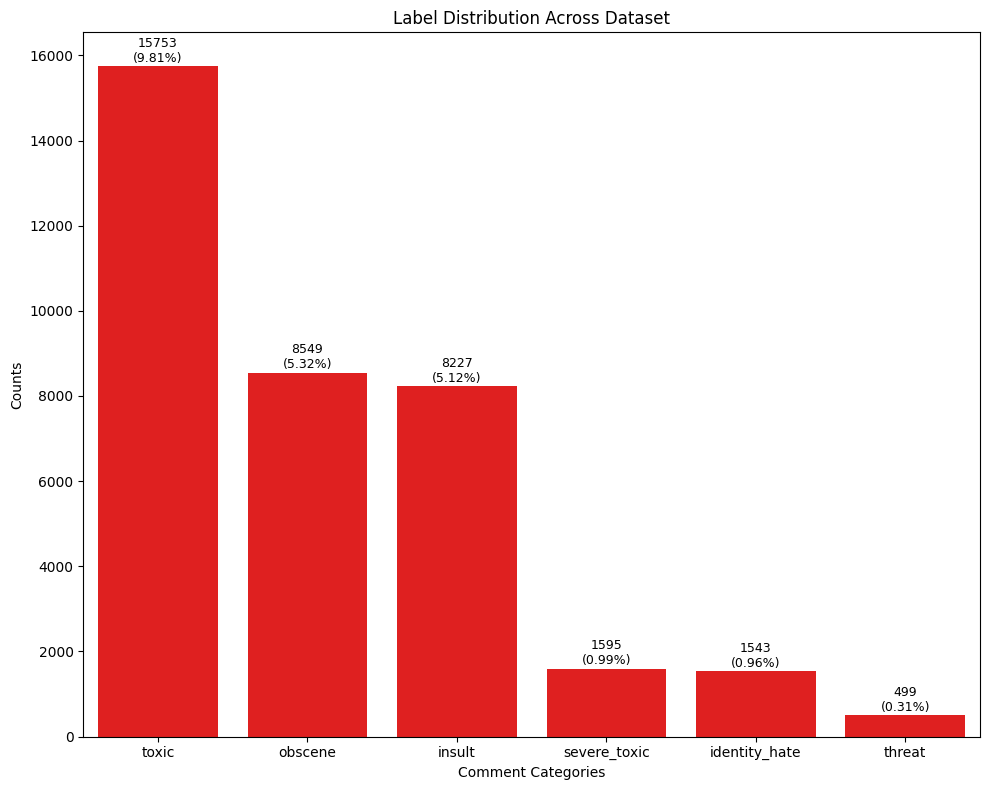


Label Summary:
               count  percentage
toxic          15753        9.81
obscene         8549        5.32
insult          8227        5.12
severe_toxic    1595        0.99
identity_hate   1543        0.96
threat           499        0.31


In [140]:
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
label_counts = df[label_cols].sum().sort_values(ascending=False)
label_pcts = (label_counts / len(df) * 100).round(2)

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=label_counts.index, y=label_counts.values,color = "#FF0000")

# Add count and percentage on each bar
for i, (count, pct) in enumerate(zip(label_counts.values, label_pcts.values)):
    ax.text(i, count + 100, f'{count}\n({pct}%)', ha='center', fontsize=9)

plt.title('Label Distribution Across Dataset')
plt.xlabel('Comment Categories')
plt.ylabel('Counts')
plt.tight_layout()
plt.show()

# Also print as table
print("\nLabel Summary:")
summary = pd.DataFrame({'count': label_counts, 'percentage': label_pcts})
print(summary)

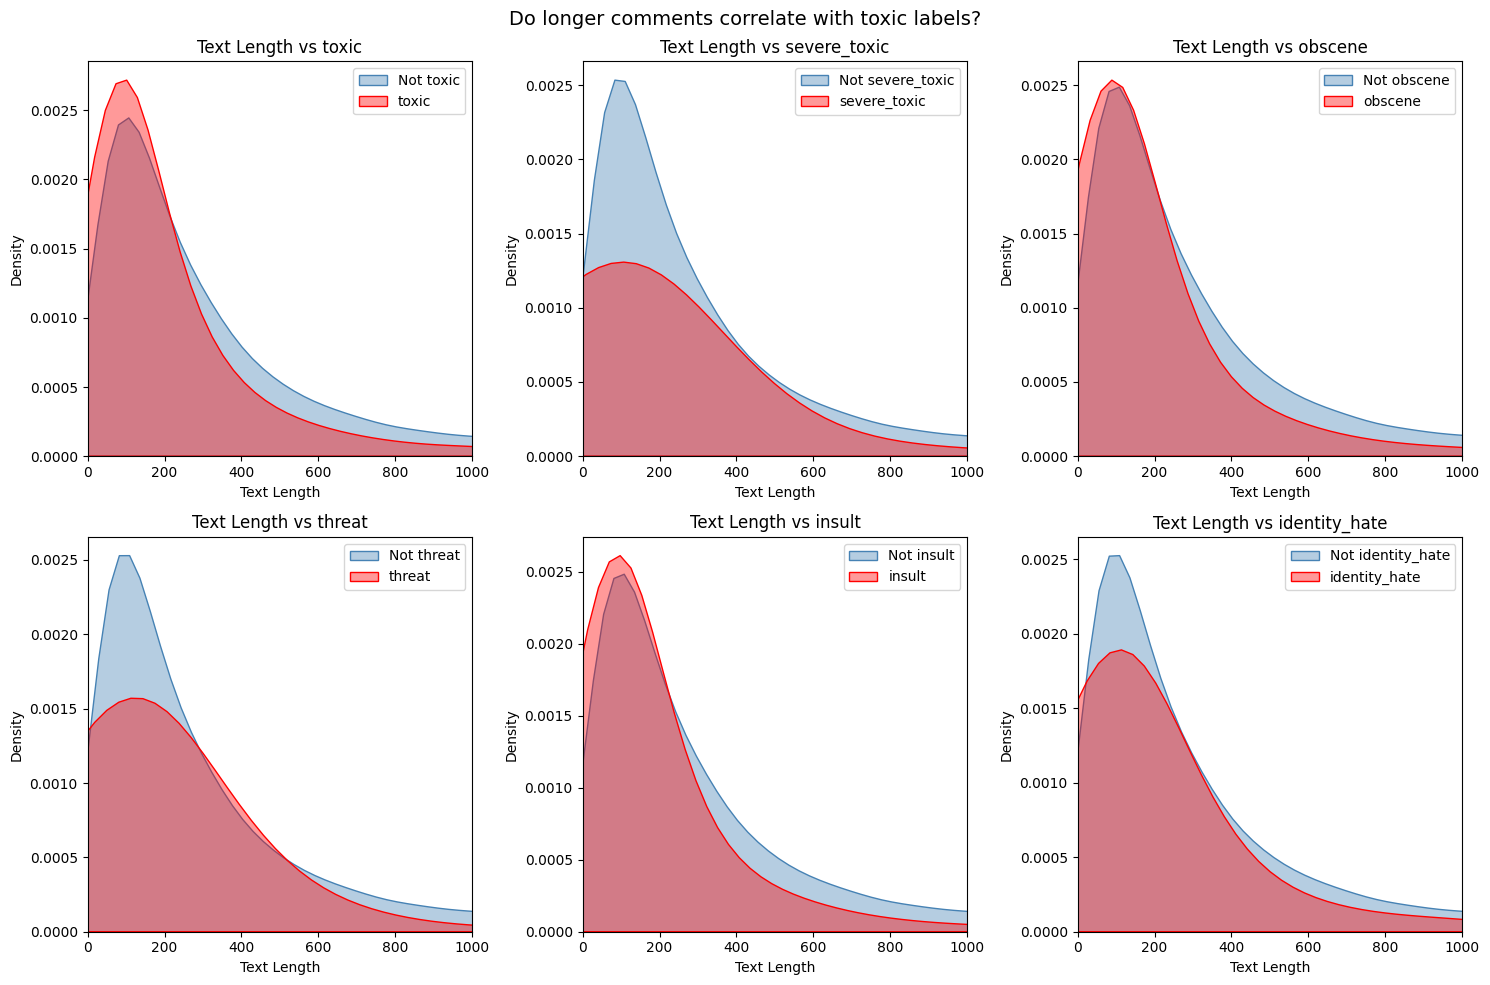

In [144]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, label in enumerate(label_cols):
    sns.kdeplot(data=df[df[label]==0]['text_length'],
                ax=axes[i], label='Not ' + label,
                color='steelblue', fill=True, alpha=0.4)
    sns.kdeplot(data=df[df[label]==1]['text_length'],
                ax=axes[i], label=label,
                color='red', fill=True, alpha=0.4)
    axes[i].set_xlim(0, 1000)
    axes[i].set_title(f'Text Length vs {label}')
    axes[i].set_xlabel('Text Length')
    axes[i].legend()

plt.suptitle('Do longer comments correlate with toxic labels?', fontsize=14)
plt.tight_layout()
plt.show()

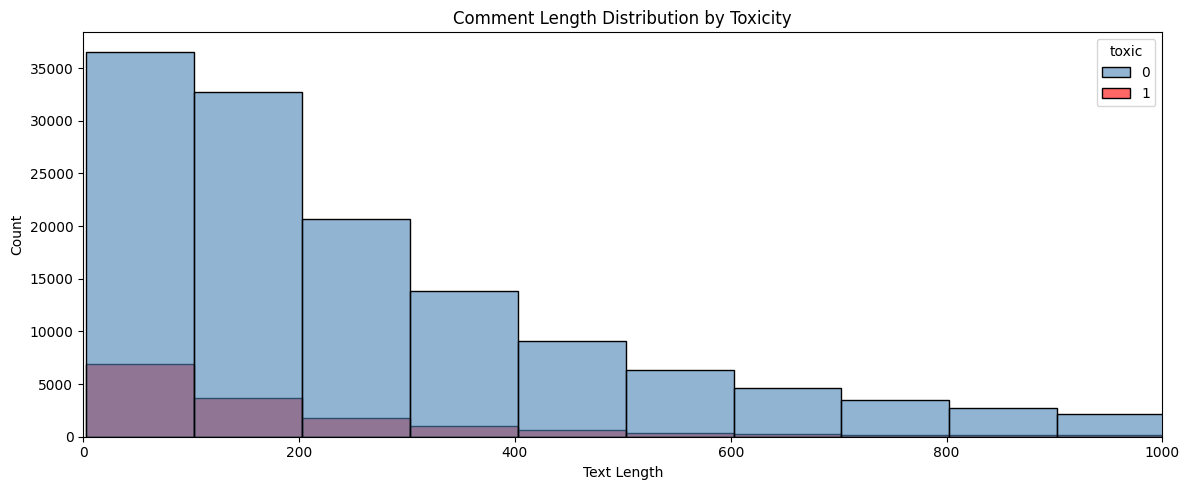

In [148]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='text_length', hue='toxic',
             bins=50, palette={0: 'steelblue', 1: 'red'},
             alpha=0.6)

plt.xlim(0, 1000)
plt.title('Comment Length Distribution by Toxicity')
plt.xlabel('Text Length')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Alright so the data is not greatly balanced, we will have to be carfeul later in training

In [150]:
df = df.drop('text_length', axis=1)

In [151]:
df.to_csv('processed_toxicity.csv', index=False)
df2.to_csv('processed_spam.csv', index=False)

In [152]:
from google.colab import files
files.download('processed_toxicity.csv')
files.download('processed_spam.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>